In [14]:
from pathlib import Path
import numpy as np
import json

In [15]:
import json
import numpy as np
from pathlib import Path


def get_detail_result(path):

    result_dir = Path(path)
    json_files = sorted(result_dir.glob("*.json"))

    cohorts = [
        "all",
        "stable",
        "converter",
        "forward_converter",
        "reverse_converter",
        "mixed_converter",
    ]

    time_names = [
        "current",
        "6_month",
        "12_month",
        "24_month",
    ]

    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]

    class_names = [
        "CN",
        "MCI",
        "AD",
    ]

    # =========================================================
    # Initialize results
    # =========================================================

    results = {}

    for cohort in cohorts:

        results[cohort] = {

            # -------------------------------------------------
            # Overall classification metrics
            # -------------------------------------------------
            "overall": {
                metric: []
                for metric in metric_names
            },

            # -------------------------------------------------
            # Overall per-class metrics
            # -------------------------------------------------
            "overall_per_class": {
                class_name: {
                    metric: []
                    for metric in [
                        "precision",
                        "recall",
                        "f1",
                    ]
                }
                for class_name in class_names
            },

            # -------------------------------------------------
            # By timepoint
            # -------------------------------------------------
            "by_time": {
                time: {

                    "metrics": {
                        metric: []
                        for metric in metric_names
                    },

                    "per_class": {
                        class_name: {
                            metric: []
                            for metric in [
                                "precision",
                                "recall",
                                "f1",
                            ]
                        }
                        for class_name in class_names
                    },

                }
                for time in time_names
            },

            # -------------------------------------------------
            # Sequence
            # -------------------------------------------------
            "sequence": {
                "subject_count": [],
                "exact_sequence_accuracy": [],
                "mean_timepoints_correct": [],
            },

            # -------------------------------------------------
            # Transitions
            # -------------------------------------------------
            "transitions": {
                "transition_count": [],
                "changed_transition_count": [],
                "exact_delta_accuracy": [],
                "direction_accuracy": [],
                "transition_mae": [],
                "changed_transition_accuracy": [],
                "changed_transition_direction_accuracy": [],
            },
        }

    # =========================================================
    # Read JSON files
    # =========================================================

    for json_file in json_files:

        with open(json_file, "r") as f:
            data = json.load(f)

        for cohort in cohorts:

            cohort_data = data[cohort]

            # =================================================
            # Overall
            # =================================================

            overall = cohort_data["overall"]

            for metric in metric_names:

                results[cohort]["overall"][metric].append(
                    overall[metric]
                )

            # -------------------------------------------------
            # Overall per-class
            # -------------------------------------------------

            for class_name in class_names:

                per_class = overall["per_class"][class_name]

                for metric in [
                    "precision",
                    "recall",
                    "f1",
                ]:

                    results[cohort][
                        "overall_per_class"
                    ][class_name][metric].append(
                        per_class[metric]
                    )

            # =================================================
            # By timepoint
            # =================================================

            for time in time_names:

                time_data = cohort_data[
                    "by_time"
                ][time]

                # ---------------------------------------------
                # Classification metrics
                # ---------------------------------------------

                for metric in metric_names:

                    results[cohort][
                        "by_time"
                    ][time]["metrics"][metric].append(
                        time_data[metric]
                    )

                # ---------------------------------------------
                # Per-class metrics
                # ---------------------------------------------

                for class_name in class_names:

                    per_class = time_data[
                        "per_class"
                    ][class_name]

                    for metric in [
                        "precision",
                        "recall",
                        "f1",
                    ]:

                        results[cohort][
                            "by_time"
                        ][time][
                            "per_class"
                        ][class_name][metric].append(
                            per_class[metric]
                        )

            # =================================================
            # Sequence
            # =================================================

            sequence = cohort_data["sequence"]

            for metric in [
                "subject_count",
                "exact_sequence_accuracy",
                "mean_timepoints_correct",
            ]:

                results[cohort][
                    "sequence"
                ][metric].append(
                    sequence[metric]
                )

            # =================================================
            # Transitions
            # =================================================

            transitions = cohort_data[
                "transitions"
            ]

            for metric in [
                "exact_delta_accuracy",
                "direction_accuracy",
                "transition_mae",
                "changed_transition_accuracy",
                "changed_transition_direction_accuracy",
            ]:

                results[cohort][
                    "transitions"
                ][metric].append(
                    transitions[metric]
                )

    return results


In [16]:
def calculate_mean_sd(results):

    summary = {}

    for cohort, cohort_data in results.items():

        summary[cohort] = {

            # =================================================
            # Overall
            # =================================================
            "overall": {},

            "overall_per_class": {},

            # =================================================
            # By time
            # =================================================
            "by_time": {},

            # =================================================
            # Sequence
            # =================================================
            "sequence": {},

            # =================================================
            # Transitions
            # =================================================
            "transitions": {},
        }

        # =====================================================
        # Overall
        # =====================================================

        for metric, values in (
            cohort_data["overall"].items()
        ):

            values = np.asarray(
                values,
                dtype=float,
            )

            summary[cohort][
                "overall"
            ][metric] = {
                "mean": np.nanmean(values),
                "sd": np.nanstd(
                    values,
                    ddof=1,
                ),
                "mean_sd": (
                    f"{np.nanmean(values):.4f} ± "
                    f"{np.nanstd(values, ddof=1):.4f}"
                ),
            }

        # =====================================================
        # Overall per-class
        # =====================================================

        for class_name, class_data in (
            cohort_data[
                "overall_per_class"
            ].items()
        ):

            summary[cohort][
                "overall_per_class"
            ][class_name] = {}

            for metric, values in class_data.items():

                values = np.asarray(
                    values,
                    dtype=float,
                )

                summary[cohort][
                    "overall_per_class"
                ][class_name][metric] = {
                    "mean": np.nanmean(values),
                    "sd": np.nanstd(
                        values,
                        ddof=1,
                    ),
                    "mean_sd": (
                        f"{np.nanmean(values):.4f} ± "
                        f"{np.nanstd(values, ddof=1):.4f}"
                    ),
                }

        # =====================================================
        # By time
        # =====================================================

        for time, time_data in (
            cohort_data["by_time"].items()
        ):

            summary[cohort][
                "by_time"
            ][time] = {
                "metrics": {},
                "per_class": {},
            }

            # -------------------------------------------------
            # Metrics
            # -------------------------------------------------

            for metric, values in (
                time_data["metrics"].items()
            ):

                values = np.asarray(
                    values,
                    dtype=float,
                )

                summary[cohort][
                    "by_time"
                ][time][
                    "metrics"
                ][metric] = {
                    "mean": np.nanmean(values),
                    "sd": np.nanstd(
                        values,
                        ddof=1,
                    ),
                    "mean_sd": (
                        f"{np.nanmean(values):.4f} ± "
                        f"{np.nanstd(values, ddof=1):.4f}"
                    ),
                }

            # -------------------------------------------------
            # Per-class
            # -------------------------------------------------

            for class_name, class_data in (
                time_data["per_class"].items()
            ):

                summary[cohort][
                    "by_time"
                ][time][
                    "per_class"
                ][class_name] = {}

                for metric, values in class_data.items():

                    values = np.asarray(
                        values,
                        dtype=float,
                    )

                    summary[cohort][
                        "by_time"
                    ][time][
                        "per_class"
                    ][class_name][metric] = {
                        "mean": np.nanmean(values),
                        "sd": np.nanstd(
                            values,
                            ddof=1,
                        ),
                        "mean_sd": (
                            f"{np.nanmean(values):.4f} ± "
                            f"{np.nanstd(values, ddof=1):.4f}"
                        ),
                    }

        # =====================================================
        # Sequence
        # =====================================================

        for metric, values in (
            cohort_data["sequence"].items()
        ):

            values = np.asarray(
                values,
                dtype=float,
            )

            summary[cohort][
                "sequence"
            ][metric] = {
                "mean": np.nanmean(values),
                "sd": np.nanstd(
                    values,
                    ddof=1,
                ),
                "mean_sd": (
                    f"{np.nanmean(values):.4f} ± "
                    f"{np.nanstd(values, ddof=1):.4f}"
                ),
            }

        # =====================================================
        # Transitions
        # =====================================================

        for metric, values in (
            cohort_data["transitions"].items()
        ):

            values = np.asarray(
                values,
                dtype=float,
            )

            summary[cohort][
                "transitions"
            ][metric] = {
                "mean": np.nanmean(values),
                "sd": np.nanstd(
                    values,
                    ddof=1,
                ),
                "mean_sd": (
                    f"{np.nanmean(values):.4f} ± "
                    f"{np.nanstd(values, ddof=1):.4f}"
                ),
            }

    return summary


In [17]:
results = get_detail_result("../results/cv/proposed_with_mean_standarization")
summary = calculate_mean_sd(results)

/tmp/ipykernel_3214105/42693464.py:218: RuntimeWarning: Mean of empty slice
  "mean": np.nanmean(values),
/root/data/github/AD_progression_visualization/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3214105/42693464.py:224: RuntimeWarning: Mean of empty slice
  f"{np.nanmean(values):.4f} ± "
/tmp/ipykernel_3214105/42693464.py:164: RuntimeWarning: Mean of empty slice
  "mean": np.nanmean(values),
/tmp/ipykernel_3214105/42693464.py:170: RuntimeWarning: Mean of empty slice
  f"{np.nanmean(values):.4f} ± "


In [18]:

with open("../results/proposed_cv_summary_mean_standarization_all_modaity.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4,  ensure_ascii=False,)

In [19]:
import json

with open("../results/proposed_cv_summary_mean_standarization_all_modaity.json", "r", encoding="utf-8") as f:
    summary = json.load(f,)

In [20]:
import pandas as pd

rows = []

for cohort, cohort_data in summary.items():

    rows.append({
        "cohort": cohort,
        "class": "overall",
        "precision": cohort_data["overall"]["macro_precision"]["mean_sd"],
        "recall": cohort_data["overall"]["macro_recall"]["mean_sd"],
        "f1": cohort_data["overall"]["macro_f1"]["mean_sd"],
    })

    for class_name, class_data in cohort_data["overall_per_class"].items():

        rows.append({
            "cohort": cohort,
            "class": class_name,
            "precision": class_data["precision"]["mean_sd"],
            "recall": class_data["recall"]["mean_sd"],
            "f1": class_data["f1"]["mean_sd"],
        })

df = pd.DataFrame(rows)

print(df)


               cohort    class        precision           recall  \
0                 all  overall  0.8557 ± 0.0227  0.8569 ± 0.0188   
1                 all       CN  0.8658 ± 0.0637  0.8827 ± 0.0405   
2                 all      MCI  0.7771 ± 0.0290  0.7916 ± 0.0526   
3                 all       AD  0.9241 ± 0.0104  0.8965 ± 0.0206   
4              stable  overall  0.8704 ± 0.0243  0.8727 ± 0.0211   
5              stable       CN  0.8787 ± 0.0635  0.9017 ± 0.0335   
6              stable      MCI  0.7903 ± 0.0363  0.8002 ± 0.0576   
7              stable       AD  0.9423 ± 0.0101  0.9163 ± 0.0224   
8           converter  overall  0.7078 ± 0.0360  0.6867 ± 0.0741   
9           converter       CN  0.6271 ± 0.0844  0.5679 ± 0.2244   
10          converter      MCI  0.7262 ± 0.0638  0.7584 ± 0.0627   
11          converter       AD  0.7699 ± 0.0363  0.7340 ± 0.0801   
12  forward_converter  overall  0.7369 ± 0.0378  0.7552 ± 0.1067   
13  forward_converter       CN  0.6747 ± 0.1026 

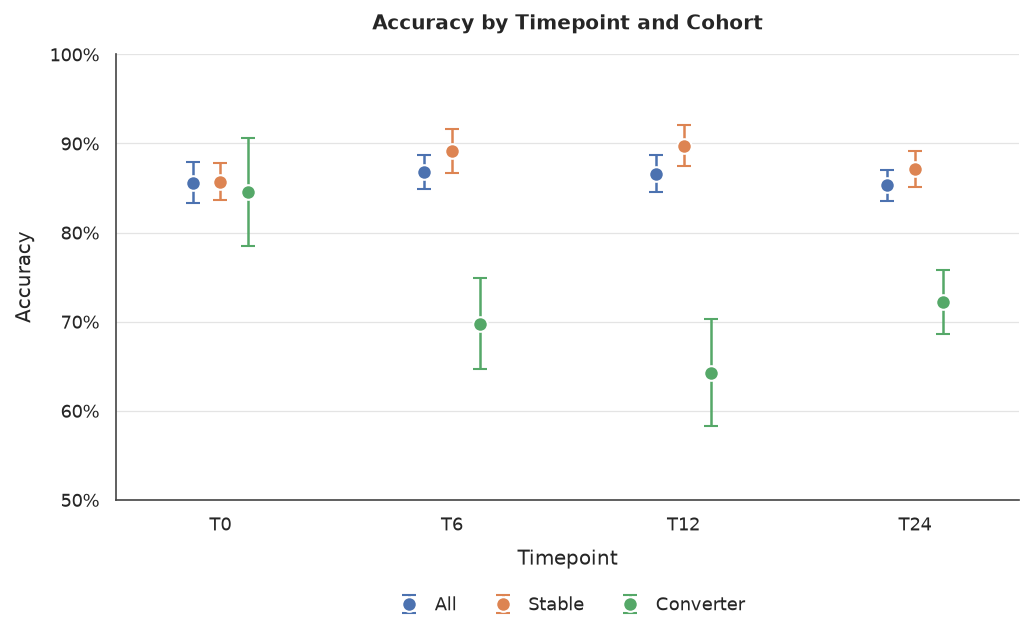

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter


# ============================================================
# Publication style
# ============================================================

sns.set_theme(
    style="white",
    context="paper",
)



# ============================================================
# Settings
# ============================================================

cohorts = [
    "all",
    "stable",
    "converter",
]

cohort_labels = {
    "all": "All",
    "stable": "Stable",
    "converter": "Converter",
}

time_names = [
    "current",
    "6_month",
    "12_month",
    "24_month",
]

# X-axis labels
time_labels = [
    "T0",
    "T6",
    "T12",
    "T24",
]


# ============================================================
# Default Seaborn palette
# ============================================================

palette = sns.color_palette()

colors = {
    "all": palette[0],
    "stable": palette[1],
    "converter": palette[2],
}


# ============================================================
# Horizontal offsets
# ============================================================

offsets = {
    "all": -0.12,
    "stable": 0.00,
    "converter": 0.12,
}


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.0, 4.5)
)


# ============================================================
# Plot accuracy
# ============================================================

x = np.arange(len(time_names))

for cohort in cohorts:

    means = []
    sds = []

    for time in time_names:

        metric = (
            summary[cohort]
            ["by_time"]
            [time]
            ["metrics"]
            ["accuracy"]
        )

        means.append(metric["mean"])
        sds.append(metric["sd"])

    means = np.asarray(
        means,
        dtype=float,
    )

    sds = np.asarray(
        sds,
        dtype=float,
    )

    # Shift x position for each cohort
    x_position = x + offsets[cohort]

    ax.errorbar(
        x_position,
        means,
        yerr=sds,

        # Point
        fmt="o",

        color=colors[cohort],

        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.0,

        # Error bars
        elinewidth=1.2,
        capsize=3.5,
        capthick=1.2,

        # No connecting line
        linestyle="none",

        label=cohort_labels[cohort],

        zorder=3,
    )


# ============================================================
# Title
# ============================================================

ax.set_title(
    "Accuracy by Timepoint and Cohort",
    pad=12,
    fontweight="bold",
)


# ============================================================
# Axis labels
# ============================================================

ax.set_xlabel(
    "Timepoint",
    labelpad=7,
)

ax.set_ylabel(
    "Accuracy",
    labelpad=7,
)


# ============================================================
# X axis
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    time_labels
)

ax.set_xlim(
    -0.45,
    len(time_names) - 0.55,
)


# ============================================================
# Y axis
# ============================================================

ax.set_ylim(
    0.50,
    1.00,
)

ax.set_yticks(
    np.arange(
        0.50,
        1.01,
        0.10,
    )
)

# Show values as percentages
ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1.0,
        decimals=0,
    )
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    axis="y",
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.7,
)

ax.grid(
    axis="x",
    visible=False,
)


# ============================================================
# Spines
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)


# ============================================================
# Ticks
# ============================================================

ax.tick_params(
    axis="both",
    which="major",
    length=4,
    width=0.7,
    color="#444444",
)

ax.tick_params(
    axis="x",
    pad=4,
)

ax.tick_params(
    axis="y",
    pad=4,
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),

    ncol=3,

    frameon=False,

    handletextpad=0.4,
    columnspacing=1.5,

    borderaxespad=0,
)


# ============================================================
# Layout
# ============================================================

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.88,
    bottom=0.22,
)


# ============================================================
# Save
# ============================================================

plt.savefig(
    "../results/accuracy_by_time_cohort.png",
    dpi=600,
    bbox_inches="tight",
)


# ============================================================
# Display
# ============================================================

plt.show()


In [21]:
import json

with open("../results/ensembled_ensemble_proposed_with_mean_standarization/result_test_set_ensemble.json", "r", encoding="utf-8") as f:
    ensemble_result = json.load(f,)

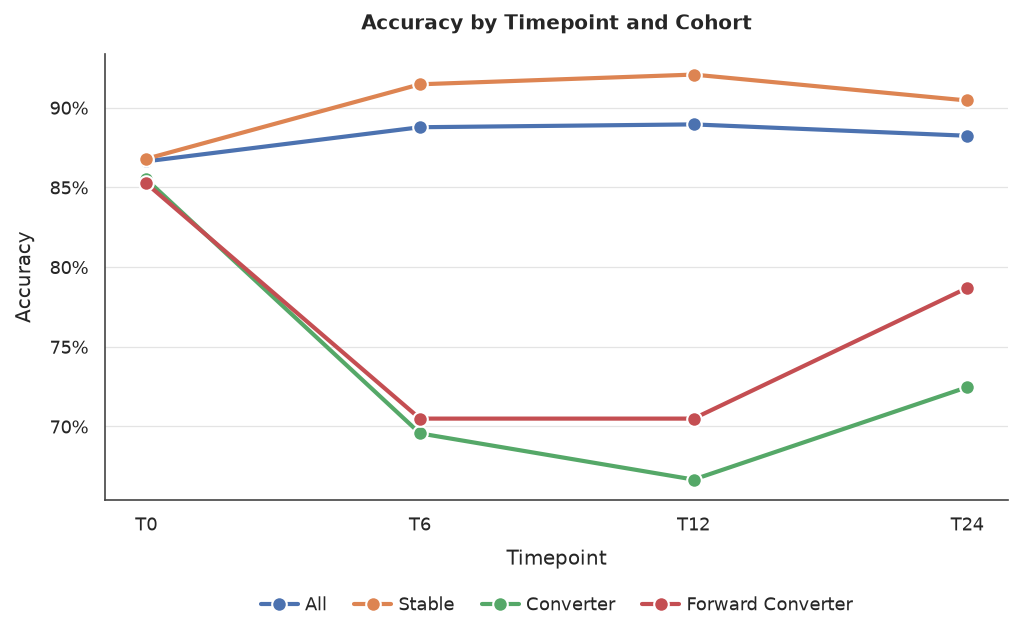

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter


# ============================================================
# Publication style
# ============================================================

sns.set_theme(
    style="white",
    context="paper",
)


# ============================================================
# Settings
# ============================================================

cohorts = [
    "all",
    "stable",
    "converter",
    "forward_converter"
]

cohort_labels = {
    "all": "All",
    "stable": "Stable",
    "converter": "Converter",
    "forward_converter": "Forward Converter"
}

time_names = [
    "current",
    "6_month",
    "12_month",
    "24_month",
]

time_labels = [
    "T0",
    "T6",
    "T12",
    "T24",
]


# ============================================================
# Default Seaborn palette
# ============================================================

palette = sns.color_palette()

colors = {
    "all": palette[0],
    "stable": palette[1],
    "converter": palette[2],
    "forward_converter": palette[3],
}


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.0, 4.5)
)


# ============================================================
# Plot values
# ============================================================

x = np.arange(len(time_names))

for cohort in cohorts:

    values = []

    for time in time_names:

        value = (
            ensemble_result[cohort]
            ["by_time"]
            [time]
            ["accuracy"]
        )

        values.append(value)

    values = np.asarray(
        values,
        dtype=float,
    )

    ax.plot(
        x,
        values,

        color=colors[cohort],

        # Line
        linewidth=2.0,

        # Points
        marker="o",
        markersize=7,
        markeredgecolor="white",
        markeredgewidth=1.0,

        label=cohort_labels[cohort],

        zorder=3,
    )


# ============================================================
# Title
# ============================================================

ax.set_title(
    "Accuracy by Timepoint and Cohort",
    pad=12,
    fontweight="bold",
)


# ============================================================
# Axis labels
# ============================================================

ax.set_xlabel(
    "Timepoint",
    labelpad=7,
)

ax.set_ylabel(
    "Accuracy",
    labelpad=7,
)


# ============================================================
# X axis
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    time_labels
)

ax.set_xlim(
    -0.15,
    len(time_names) - 0.85,
)


# ============================================================
# Y axis
# ============================================================

# ax.set_ylim(
#     0.50,
#     1.00,
# )

# ax.set_yticks(
#     np.arange(
#         0.20,
#         1.01,
#         0.10,
#     )
# )

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1.0,
        decimals=0,
    )
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    axis="y",
    color="#D9D9D9",
    linewidth=0.6,
    alpha=0.7,
)

ax.grid(
    axis="x",
    visible=False,
)


# ============================================================
# Spines
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)


# ============================================================
# Ticks
# ============================================================

ax.tick_params(
    axis="both",
    which="major",
    length=4,
    width=0.7,
    color="#444444",
)

ax.tick_params(
    axis="x",
    pad=4,
)

ax.tick_params(
    axis="y",
    pad=4,
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),

    ncol=4,

    frameon=False,

    handletextpad=0.4,
    columnspacing=1.5,

    borderaxespad=0,
)


# ============================================================
# Layout
# ============================================================

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.88,
    bottom=0.22,
)


# ============================================================
# Save
# ============================================================

plt.savefig(
    "../results/ensembled_accuracy_by_time_cohort.png",
    dpi=600,
    bbox_inches="tight",
)


# ============================================================
# Display
# ============================================================

plt.show()


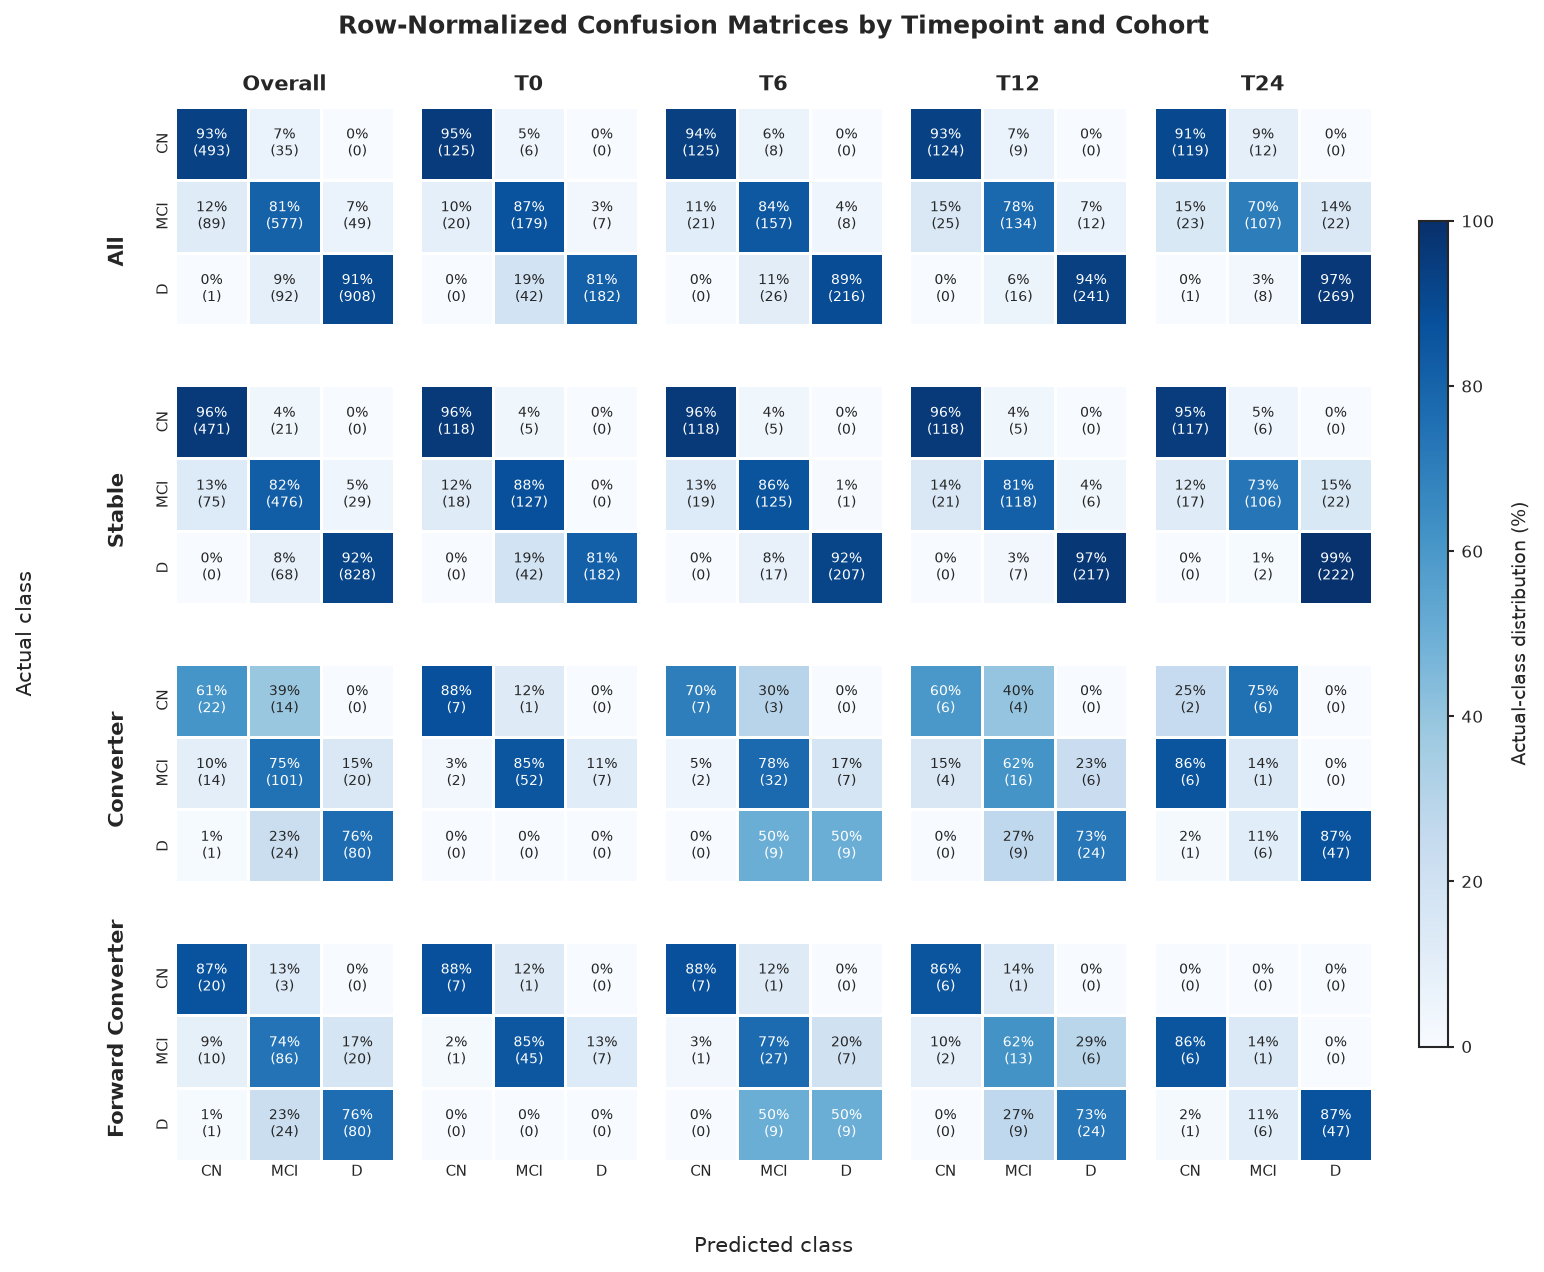

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Publication style
# ============================================================

sns.set_theme(
    style="white",
    context="paper",
)


# ============================================================
# Settings
# ============================================================

cohorts = [
    "all",
    "stable",
    "converter",
    "forward_converter",
]

cohort_labels = {
    "all": "All",
    "stable": "Stable",
    "converter": "Converter",
    "forward_converter": "Forward Converter",
}

time_names = [
    "overall",
    "current",
    "6_month",
    "12_month",
    "24_month",
]

time_labels = [
    "Overall",
    "T0",
    "T6",
    "T12",
    "T24",
]

class_labels = [
    "CN",
    "MCI",
    "D",
]


# ============================================================
# Collect confusion matrices
# ============================================================

confusion_matrices = {}

for cohort in cohorts:

    confusion_matrices[cohort] = {}

    confusion_matrices[cohort]["overall"] = np.asarray(
        ensemble_result[cohort]
        ["overall"]
        ["confusion_matrix"],
        dtype=float,
    )

    for time in time_names[1:]:

        confusion_matrices[cohort][time] = np.asarray(
            ensemble_result[cohort]
            ["by_time"]
            [time]
            ["confusion_matrix"],
            dtype=float,
        )


# ============================================================
# Row-normalize
#
# Each row = one actual class.
# Each row therefore sums to 100%.
# ============================================================

normalized_matrices = {}

for cohort in cohorts:

    normalized_matrices[cohort] = {}

    for time in time_names:

        matrix = confusion_matrices[cohort][time]

        row_sums = matrix.sum(
            axis=1,
            keepdims=True,
        )

        normalized_matrix = np.divide(
            matrix,
            row_sums,
            out=np.zeros_like(matrix, dtype=float),
            where=row_sums != 0,
        )

        normalized_matrices[cohort][time] = (
            normalized_matrix * 100
        )


# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=len(cohorts),
    ncols=len(time_names),
    figsize=(10.5, 8.6),
)


# ============================================================
# Plot heatmaps
# ============================================================

for row, cohort in enumerate(cohorts):

    for col, time in enumerate(time_names):

        ax = axes[row, col]

        # Raw counts
        count_matrix = confusion_matrices[cohort][time]

        # Row-normalized percentages
        percent_matrix = normalized_matrices[cohort][time]

        # ----------------------------------------------------
        # Create percentage + count annotations
        # ----------------------------------------------------

        annotations = np.empty(
            percent_matrix.shape,
            dtype=object,
        )

        for i in range(percent_matrix.shape[0]):

            for j in range(percent_matrix.shape[1]):

                percentage = percent_matrix[i, j]
                count = count_matrix[i, j]

                annotations[i, j] = (
                    f"{percentage:.0f}%\n"
                    f"({count:.0f})"
                )

        # ----------------------------------------------------
        # Heatmap
        # ----------------------------------------------------

        sns.heatmap(
            percent_matrix,

            ax=ax,

            cmap="Blues",

            # Fixed 0–100% scale for every panel
            vmin=0,
            vmax=100,

            annot=annotations,
            fmt="",

            annot_kws={
                "fontsize": 6.5,
                "ha": "center",
                "va": "center",
            },

            linewidths=0.7,
            linecolor="white",

            square=True,

            xticklabels=class_labels,
            yticklabels=class_labels,

            # One shared colorbar
            cbar=False,
        )

        # ----------------------------------------------------
        # Column titles
        # ----------------------------------------------------

        if row == 0:

            ax.set_title(
                time_labels[col],
                fontsize=10,
                fontweight="bold",
                pad=8,
            )

        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------

        ax.set_xlabel("")
        ax.set_ylabel("")

        # ----------------------------------------------------
        # Y-axis labels
        # ----------------------------------------------------

        if col != 0:

            ax.set_yticklabels([])

        # ----------------------------------------------------
        # X-axis labels
        # ----------------------------------------------------

        if row != len(cohorts) - 1:

            ax.set_xticklabels([])

        # ----------------------------------------------------
        # Tick styling
        # ----------------------------------------------------

        ax.tick_params(
            axis="both",
            which="major",
            length=0,
            pad=2,
            labelsize=7,
        )


# ============================================================
# Cohort labels
# ============================================================

for row, cohort in enumerate(cohorts):

    pos = axes[row, 0].get_position()

    fig.text(
        pos.x0 - 0.035,
        (pos.y0 + pos.y1) / 2,

        cohort_labels[cohort],

        ha="right",
        va="center",

        fontsize=10,
        fontweight="bold",

        rotation=90,
    )


# ============================================================
# Global axis labels
# ============================================================

fig.text(
    0.50,
    0.025,

    "Predicted class",

    ha="center",
    va="center",

    fontsize=10,
)

fig.text(
    0.025,
    0.50,

    "Actual class",

    ha="center",
    va="center",

    rotation=90,

    fontsize=10,
)


# ============================================================
# Shared colorbar
# ============================================================

cbar_ax = fig.add_axes([
    0.91,
    0.18,
    0.018,
    0.64,
])

sm = plt.cm.ScalarMappable(
    cmap="Blues",
    norm=plt.Normalize(
        vmin=0,
        vmax=100,
    ),
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
)

cbar.set_label(
    "Actual-class distribution (%)",
    fontsize=9,
    labelpad=8,
)

cbar.set_ticks([
    0,
    20,
    40,
    60,
    80,
    100,
])

cbar.ax.tick_params(
    labelsize=8,
    length=3,
)


# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    "Row-Normalized Confusion Matrices by Timepoint and Cohort",
    fontsize=12,
    fontweight="bold",
    y=0.98,
)


# ============================================================
# Layout
# ============================================================

fig.subplots_adjust(
    left=0.12,
    right=0.88,
    top=0.91,
    bottom=0.09,

    wspace=0.12,
    hspace=0.25,
)


# ============================================================
# Save high-resolution PNG
# ============================================================

plt.savefig(
    "../results/"
    "confusion_matrices_row_normalized.png",

    dpi=600,

    bbox_inches="tight",

    facecolor="white",
)


# ============================================================
# Save vector PDF
# ============================================================

plt.savefig(
    "../results/"
    "confusion_matrices_row_normalized.pdf",

    bbox_inches="tight",

    facecolor="white",
)


# ============================================================
# Display
# ============================================================

plt.show()
